In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv('../data/processed/features_completo.csv')

print(f'Shape: {df.shape}')
df.head()

Shape: (248, 10)


,media_gols_marcados_ciclo,media_gols_sofridos_ciclo,pct_vitorias_ciclo,total_jogos_ciclo,media_gols_marcados_ult15,media_gols_sofridos_ult15,pct_vitorias_ult15,media_gols_copa,selecao,copa_alvo
0,1.975610,0.975610,0.609756,41,2.533333,1.066667,0.666667,1.800000,Germany,1994
1,1.023810,1.190476,0.214286,42,0.600000,1.133333,0.133333,0.333333,Bolivia,1994
2,1.885714,0.914286,0.514286,35,2.266667,0.733333,0.666667,2.000000,Spain,1994
3,1.750000,0.625000,0.517857,56,1.533333,1.066667,0.333333,1.333333,South Korea,1994
4,1.279070,0.604651,0.465116,43,1.733333,0.400000,0.600000,1.333333,Colombia,1994


In [2]:
# Separar features (X) e target (y)
features = [
    'media_gols_marcados_ciclo',
    'media_gols_sofridos_ciclo',
    'pct_vitorias_ciclo',
    'total_jogos_ciclo',
    'media_gols_marcados_ult15',
    'media_gols_sofridos_ult15',
    'pct_vitorias_ult15'
]

X = df[features]
y = df['media_gols_copa']

# Divisão temporal — treino: 1994-2018, teste: 2022
X_train = X[df['copa_alvo'] < 2022]
X_test  = X[df['copa_alvo'] == 2022]
y_train = y[df['copa_alvo'] < 2022]
y_test  = y[df['copa_alvo'] == 2022]

print(f'Treino: {X_train.shape[0]} amostras ({sorted(df[df["copa_alvo"] < 2022]["copa_alvo"].unique())})')
print(f'Teste:  {X_test.shape[0]} amostras (Copa 2022)')

Treino: 216 amostras ([1994, 1998, 2002, 2006, 2010, 2014, 2018])
Teste:  32 amostras (Copa 2022)


In [3]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Treinar
lr = LinearRegression()
lr.fit(X_train, y_train)

# Prever
y_pred_lr = lr.predict(X_test)

# Avaliar
mae_lr = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = mean_squared_error(y_test, y_pred_lr, squared=False)

print(f'Regressão Linear')
print(f'  MAE:  {mae_lr:.4f}')
print(f'  RMSE: {rmse_lr:.4f}')

Regressão Linear
  MAE:  0.4800
  RMSE: 0.5651


c:\Users\joaog\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


In [4]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import root_mean_squared_error

# Regressão Linear (corrigido)
mae_lr = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = root_mean_squared_error(y_test, y_pred_lr)

print(f'Regressão Linear')
print(f'  MAE:  {mae_lr:.4f}')
print(f'  RMSE: {rmse_lr:.4f}')

# Random Forest
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = root_mean_squared_error(y_test, y_pred_rf)

print(f'\nRandom Forest')
print(f'  MAE:  {mae_rf:.4f}')
print(f'  RMSE: {rmse_rf:.4f}')

Regressão Linear
  MAE:  0.4800
  RMSE: 0.5651

Random Forest
  MAE:  0.4512
  RMSE: 0.5789


In [5]:
from xgboost import XGBRegressor

xgb = XGBRegressor(n_estimators=100, random_state=42)
xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)

mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
rmse_xgb = root_mean_squared_error(y_test, y_pred_xgb)

print(f'XGBoost')
print(f'  MAE:  {mae_xgb:.4f}')
print(f'  RMSE: {rmse_xgb:.4f}')

XGBoost
  MAE:  0.5603
  RMSE: 0.6874


In [6]:
resultados = pd.DataFrame({
    'Modelo': ['Regressão Linear', 'Random Forest', 'XGBoost'],
    'MAE': [mae_lr, mae_rf, mae_xgb],
    'RMSE': [rmse_lr, rmse_rf, rmse_xgb]
})

resultados = resultados.sort_values('MAE').reset_index(drop=True)
print(resultados.to_string(index=False))

          Modelo      MAE     RMSE
   Random Forest 0.451156 0.578860
Regressão Linear 0.480034 0.565093
         XGBoost 0.560300 0.687399


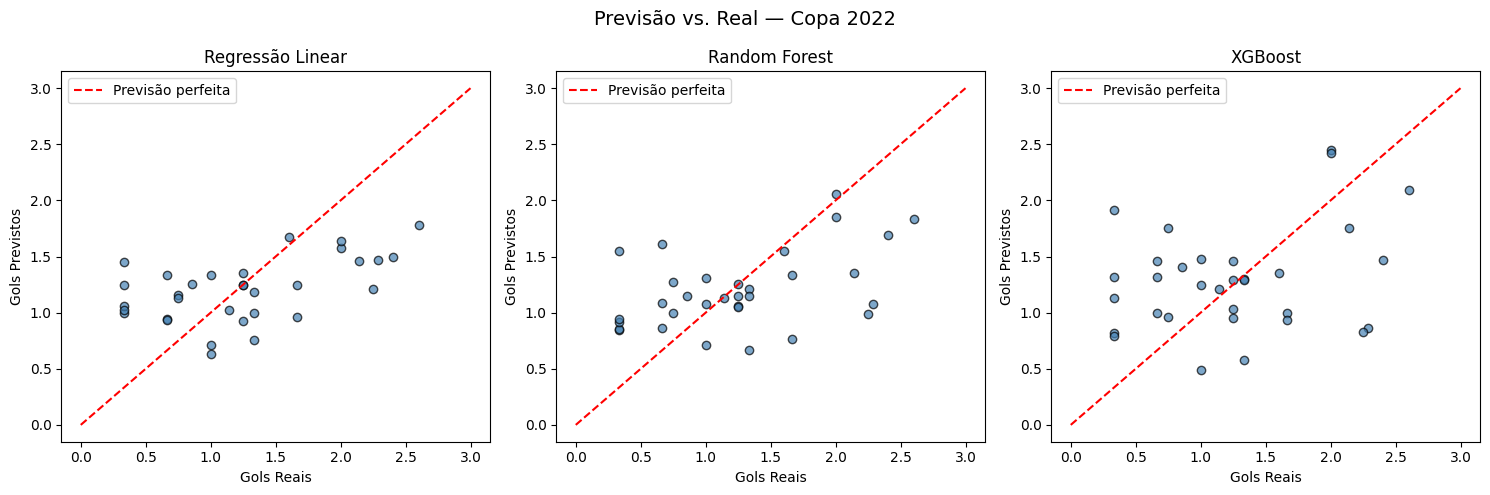

In [7]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

modelos = [
    ('Regressão Linear', y_pred_lr),
    ('Random Forest', y_pred_rf),
    ('XGBoost', y_pred_xgb)
]

for ax, (nome, y_pred) in zip(axes, modelos):
    ax.scatter(y_test, y_pred, alpha=0.7, color='steelblue', edgecolors='black')
    ax.plot([0, 3], [0, 3], 'r--', label='Previsão perfeita')
    ax.set_xlabel('Gols Reais')
    ax.set_ylabel('Gols Previstos')
    ax.set_title(nome)
    ax.legend()

plt.suptitle('Previsão vs. Real — Copa 2022', fontsize=14)
plt.tight_layout()
plt.savefig('../article/figures/modelos_comparacao.png', dpi=150, bbox_inches='tight')
plt.show()